In [2]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END, add_messages
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from ddgs import DDGS

from langgraph.prebuilt import ToolNode

llm = ChatOllama(model='qwen3:1.7b')

class AgentState(TypedDict):
    messages: Annotated[list,add_messages]

c:\Users\wengshang.hoo\AppData\Local\miniconda3\envs\ai_sl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import requests

@tool
def get_weather(location:str) -> str:
    """
    Get current weather for a location

    Use for queries about weather, temperature, or conditions in any city.

    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"
    
    Args:
        location: City name (e.g., "New York", "London", "Tokyo")
        
    Returns:
        Current weather information including temperature and conditions.
    """

    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data

@tool
def research_info(query:str) -> str:
    """
    Search any info regarding the query has been ask.

    Args:
        query: The search query

    Returns:
        Formatted search results with titles, descriptions, and URLs
    """

    results = DDGS().text(query)

    if not results:
        return "No results found"
    
    formatted_results = [f"Search results for search query: {query}\n"]

    for i, result in enumerate(results, 1):
        title = result.get('title', 'No title')
        href = result.get('href', '')
        body = result.get('body', 'No description available')

        text = f"{i}. **{title}**\n   {body}\n   {href}"

        formatted_results.append(text)

    return "\n\n".join(formatted_results)


In [4]:
all_tools = [get_weather,research_info]
llm_with_tools = llm.bind_tools(all_tools)

In [5]:
def agent_node(state: AgentState):

    system_prompt = SystemMessage(
        f"""

        You are a helpful assistant knowing what info need to asking base on the tools you have.

        Instructions:
        1. Use an appropriate tools to answer the question if needed.
        2. Make it brief if you get the report from specific location
        """
    )

    messages = [system_prompt] + state['messages']

    response = llm_with_tools.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"Call tool {tc.get('name','')} with arguments {tc.get('args','?')}")
    else:
        print(f"No tool calling")

    return {"messages": [response]}

def should_continue(state: AgentState):
    last_message = state['messages'][-1]

    if hasattr(last_message,'tool_calls') and last_message.tool_calls:
        return 'tools'
    else:
        return END

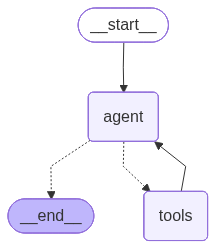

In [6]:
builder = StateGraph(AgentState)

builder.add_node("agent",agent_node)
builder.add_node("tools",ToolNode(all_tools))

builder.add_edge(START,"agent")
builder.add_conditional_edges("agent",should_continue,["tools",END])
builder.add_edge("tools","agent")

graph = builder.compile()
graph


In [7]:
r1 = graph.invoke({"messages":"hi"})
r1

No tool calling


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='88d69dc9-bc8c-4f41-b395-d59237c7cac0'),
  AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-01T11:47:30.4311512Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13893511200, 'load_duration': 2418739100, 'prompt_eval_count': 319, 'prompt_eval_duration': 7657006300, 'eval_count': 75, 'eval_duration': 3426252800, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019ca939-63b5-7413-b7ce-36c40f808df5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 319, 'output_tokens': 75, 'total_tokens': 394})]}

In [8]:
r2 = graph.invoke({"messages":"Please tell me the info about tokyo weather"})
r2

Call tool get_weather with arguments {'location': 'Tokyo'}
No tool calling


{'messages': [HumanMessage(content='Please tell me the info about tokyo weather', additional_kwargs={}, response_metadata={}, id='2e7a7105-0620-4b4c-8a0a-085f1ddf64f7'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-01T11:47:35.444775Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4990825100, 'load_duration': 307599800, 'prompt_eval_count': 328, 'prompt_eval_duration': 416963400, 'eval_count': 87, 'eval_duration': 4249707500, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019ca939-9a14-7d53-a184-2accba365df5-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'd16301ea-354a-4524-bd03-7aa80f3639f6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 328, 'output_tokens': 87, 'total_tokens': 415}),
  ToolMessage(content='{"current_condition": [{"FeelsLikeC": "15", "FeelsLikeF": "59", "cloudcover": "54", "humidity": "76", "

In [10]:
r2['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here's a structured analysis of the provided weather data, focusing on key parameters like temperature, precipitation, wind, and UV index:

---

### **1. Temperature Overview**
- **Minimum Temp (°C):** 11°C (52°F)  
- **Maximum Temp (°C):** 14°C (57°F)  
- **Trend:** Temperatures fluctuate slightly throughout the day, with the lowest values occurring in the early evening (18:00) and the highest in the early morning (00:00).  

---

### **2. Precipitation**
- **Light Rain:** Occurs in most entries (e.g., 1.0–3.5 mm/h).  
- **Moderate Rain:** Notable in the late afternoon (15:00–18:00), with 3.5 mm/h.  
- **Wind-Driven Rain:** Strong winds (50–79 mph) in late evening (21:00) and night (00:00), increasing precipitation intensity.  

---

### **3. Wind Speed**
- **Wind Gusts:**  
  - **50–79 mph (80–127 km/h):** Late evening (21:00) and night (00:00).  
  - **44–56 mph (71–90 km/h):** Early morning (06:00) an